In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv(r"C:\Users\vidisha bhat\Downloads\archive\spotify_clustered.csv")

features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 
            'valence', 'tempo', 'duration_ms', 'explicit']

X = df[features]
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split!")
print("Training size:", X_train.shape)

Data loaded and split!
Training size: (71792, 11)


In [3]:
# Add genre as a feature using one-hot encoding (top genres only to keep it manageable)
top_genres = df['track_genre'].value_counts().head(20).index
df['genre_grouped'] = df['track_genre'].apply(lambda x: x if x in top_genres else 'other')

genre_dummies = pd.get_dummies(df['genre_grouped'], prefix='genre')
print("Genre features created:", genre_dummies.shape)
print(genre_dummies.columns.tolist())

Genre features created: (89741, 21)
['genre_acoustic', 'genre_afrobeat', 'genre_alt-rock', 'genre_ambient', 'genre_anime', 'genre_black-metal', 'genre_bluegrass', 'genre_breakbeat', 'genre_cantopop', 'genre_chicago-house', 'genre_club', 'genre_comedy', 'genre_disney', 'genre_forro', 'genre_happy', 'genre_heavy-metal', 'genre_j-idol', 'genre_other', 'genre_sleep', 'genre_study', 'genre_tango']


In [4]:
# Combine audio features with genre features
X_with_genre = pd.concat([df[features], genre_dummies], axis=1)
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(X_with_genre, y, test_size=0.2, random_state=42)

# Train improved Random Forest with genre features
rf_improved = RandomForestRegressor(n_estimators=150, max_depth=18, random_state=42, n_jobs=-1)
rf_improved.fit(X_train, y_train)

y_pred_improved = rf_improved.predict(X_test)

rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
r2_improved = r2_score(y_test, y_pred_improved)

print("Improved Model Results (with genre features):")
print(f"RMSE: {rmse_improved:.2f}")
print(f"R² Score: {r2_improved:.3f}")
print(f"\nPrevious R² (without genre): 0.189")
print(f"Improvement: {r2_improved - 0.189:.3f}")

Improved Model Results (with genre features):
RMSE: 17.55
R² Score: 0.265

Previous R² (without genre): 0.189
Improvement: 0.076


In [9]:
import matplotlib.pyplot as plt

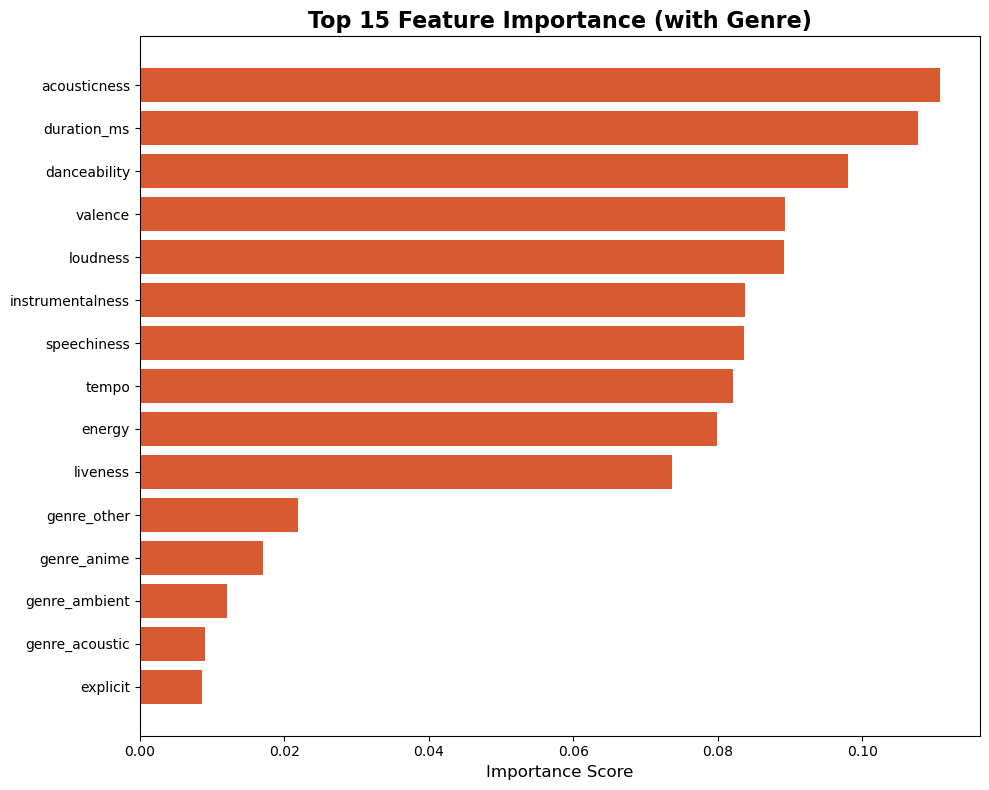

Chart saved!


In [10]:
plt.figure(figsize=(10, 8))
plt.barh(importance_v2['feature'], importance_v2['importance'], color='#D85A30')
plt.title('Top 15 Feature Importance (with Genre)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart10_feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [11]:
print("Day 8 Summary:")
print(f"Model without genre: R² = 0.189")
print(f"Model with genre features: R² = {r2_improved:.3f}")
print(f"Improvement: {((r2_improved - 0.189)/0.189*100):.1f}% relative increase")
print("\nDay 8 (Model Improvement) complete!")

Day 8 Summary:
Model without genre: R² = 0.189
Model with genre features: R² = 0.265
Improvement: 40.2% relative increase

Day 8 (Model Improvement) complete!
